In [1]:
# checks the notebook's GPU
import torch
print("CUDA:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0))
print("VRAM GB:", torch.cuda.get_device_properties(0).total_memory / 1e9)

CUDA: True
Device: NVIDIA L4
VRAM GB: 23.65915136


In [5]:
# saving data as 32*32
from PIL import Image
import os

RAW = os.path.expanduser("~/MyWork/DDPM-NeuralNetwork/data/Cubism_raw")
OUT64 = os.path.expanduser("~/MyWork/DDPM-NeuralNetwork/data/cubism_64")
os.makedirs(OUT64, exist_ok=True)

files = [f for f in os.listdir(RAW) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
print("Found raw files:", len(files), "(expected ~2235)")

for i, fname in enumerate(files):
    img = Image.open(os.path.join(RAW, fname)).convert("RGB")
    img.resize((64, 64), Image.LANCZOS).save(f"{OUT64}/{i:05d}.jpg", quality=95)

print("Saved 64:", len(os.listdir(OUT64)))

Found raw files: 2235 (expected ~2235)
Saved 64: 2235


In [6]:
# define class that charge pics from cubism_64, change and normalize them

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os

class CubismDataset(Dataset):
    def __init__(self, folder, image_size=64):
        self.paths = sorted(os.path.join(folder, f) for f in os.listdir(folder) if f.endswith(".jpg"))
        self.transform = transforms.Compose([
            transforms.Resize(image_size),
            transforms.CenterCrop(image_size),
            transforms.ToTensor(),
            transforms.Lambda(lambda t: t * 2 - 1),
        ])
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        return self.transform(Image.open(self.paths[idx]).convert("RGB"))

train_ds = CubismDataset(os.path.expanduser("~/MyWork/DDPM-NeuralNetwork/data/cubism_64"), image_size=64)
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=0, drop_last=True)
print("Dataset size:", len(train_ds))

Dataset size: 2235


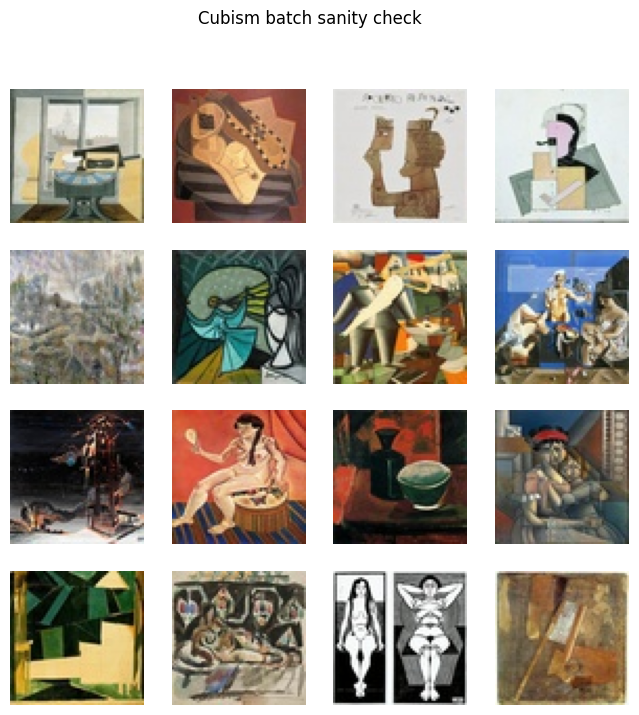

In [8]:
# visualization

import matplotlib.pyplot as plt
batch = next(iter(train_loader))
grid = (batch[:16] + 1) / 2
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(grid[i].permute(1, 2, 0).numpy()); ax.axis("off")
plt.suptitle("Cubism batch sanity check"); plt.show()